# Курсы ЦБ и оптимизация индикаторов

Ноутбук последовательно выполняет весь исследовательский pipeline:

1. загружает курсы ЦБ;
2. строит causal-признаки и targets;
3. задаёт пространства правил;
4. оптимизирует rule-based индикаторы через walk-forward;
5. продолжает WF для победивших G0/W1-архитектур с rolling train;
6. выбирает cadence и продолжает rolling WF ML-индикаторов G0/W1.


In [1]:
from datetime import date
from itertools import combinations, product
from pathlib import Path
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.cbr_loader import CURRENCIES, load_cbr_history
from src.features import build_features
from src.indicator_optimization import optimize_indicator_library
from src.indicator_backtest import backtest_selected_indicators
from src.indicators import IndicatorCandidate, IndicatorRule, create_indicator_rules
from src.market_data import build_daily_market_panel, market_snapshot
from src.ml_backtest import run_ml_indicator_backtest
from src.fast_slow_analysis import analyze_fast_slow_signals
from src.visualization import (plot_benefit_distribution, plot_fast_slow_summary,
    plot_oos_uplift, plot_rate_panel, plot_signal_series)
from src.visualization import plot_fast_slow_summary, plot_signal_series
from src.outcomes import DEFAULT_HORIZONS, add_future_outcomes, outcome_columns
from src.target_evaluation import (
    evaluate_perfect_target_lift,
    evaluate_target_family_frequency,
)
from src.targets import build_targets, target_columns

START_DATE = date(2018, 1, 1)
END_DATE = date.today()
RECIPIENT_CURRENCIES = ("AMD", "KZT", "KGS", "TJS", "UZS")

# Проверяем несколько частот переобучения как полноценный параметр оптимизации.
FIRST_TEST_DATE = "2020-01-01"
TRAIN_WINDOW_MONTHS = 24
TEST_MONTHS_OPTIONS = (3, 6, 12)
INDICATOR_MIN_SIGNALS_PER_WEEK = 2.0
ENSEMBLE_LIFT_THRESHOLDS = (1.3,)
# Discovery OOS заканчивается до 2024; сам 2024 оставлен meta-validation.
WINNER_WF_START = pd.Timestamp("2024-01-01")
WINNER_TARGET_FAMILIES = ("G0", "W1")
ML_VALIDATION_MONTHS = 12
ML_MODEL_TYPE = "hist_gradient_boosting" # "logistic_regression" "hist_gradient_boosting" "extra_trees"
ML_CURRENCIES = RECIPIENT_CURRENCIES #("KZT",)  # Для полного запуска: RECIPIENT_CURRENCIES
ML_TEST_MONTHS_OPTIONS = (12,)
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "cbr"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)


## 1. Данные ЦБ

Номиналы приводятся к рублям за одну единицу валюты. `available_at` консервативно установлен на 00:00 следующего календарного дня. Сохраняется только базовое хранилище курсов, потому что оно является входом всего исследования.


In [2]:
cbr_history = load_cbr_history(
    start_date=START_DATE,
    end_date=END_DATE,
    currencies=CURRENCIES,
    raw_dir=RAW_DIR,
)
assert cbr_history["normalized_rate"].gt(0).all()
assert cbr_history["publication_timestamp_is_proxy"].all()
assert (cbr_history["available_at"] == cbr_history["effective_date"] + pd.Timedelta(days=1)).all()
pd.testing.assert_series_equal(
    cbr_history["normalized_rate"],
    cbr_history["raw_rate"] / cbr_history["nominal"],
    check_names=False,
)

rates = (
    cbr_history.pivot(index="available_at", columns="currency", values="normalized_rate")
    .reindex(columns=list(CURRENCIES))
    .sort_index()
)
rates.columns.name = None
rates.index.name = "available_at"
assert rates.notna().all().all()
assert rates.index.is_unique and rates.index.is_monotonic_increasing

market_panel = build_daily_market_panel(rates)
latest_snapshot = market_snapshot(market_panel, as_of=market_panel["available_at"].max())
assert set(latest_snapshot["currency"]) == set(CURRENCIES)

cbr_history.to_parquet(PROCESSED_DIR / "cbr_history_temporal.parquet", index=False)
rates.to_parquet(PROCESSED_DIR / "cbr_rates.parquet")
rates.to_csv(PROCESSED_DIR / "cbr_rates.csv")

pd.DataFrame({
    "publication_dates": [len(rates)],
    "first_available_at": [rates.index.min()],
    "last_available_at": [rates.index.max()],
    "currencies": [", ".join(rates.columns)],
})


,publication_dates,first_available_at,last_available_at,currencies
0,2138,2018-01-11,2026-09-06,"AMD, KZT, KGS, TJS, UZS, USD, EUR, CNY"


## 2. Features и targets

Признаки используют только текущие и прошлые значения. Future outcomes нужны исключительно для разметки. Оптимизация выполняется только на реальных днях публикации курсов пяти целевых валют.


In [3]:
features = build_features(market_panel)
outcomes = add_future_outcomes(features, horizons=DEFAULT_HORIZONS)
dataset, target_registry = build_targets(outcomes, horizons=DEFAULT_HORIZONS)

assert set(target_registry["horizon"]) == set(DEFAULT_HORIZONS)
assert target_registry["name"].isin(dataset.columns).all()
assert len(target_columns(dataset)) == len(target_registry)
assert outcome_columns(dataset)

update_rows = dataset.loc[
    dataset["is_update_day"] & dataset["currency"].isin(RECIPIENT_CURRENCIES)
].copy()
target_prevalence = (
    update_rows[["currency", *target_registry["name"].tolist()]]
    .melt(id_vars="currency", var_name="target", value_name="value")
    .dropna(subset=["value"])
    .groupby(["currency", "target"], as_index=False)
    .agg(observations=("value", "size"), positive_rate=("value", "mean"))
    .merge(
        target_registry[["name", "scenario", "family", "horizon"]],
        left_on="target", right_on="name", how="left", validate="many_to_one",
    )
    .drop(columns="name")
)
target_prevalence.pivot_table(
    index=["scenario", "family", "target", "horizon"],
    columns="currency", values="positive_rate",
).sort_index()


currency                                                                           AMD  \
scenario       family target                                         horizon             
GOOD_NOW       G0     target_g0_exact_min_h10d                       10       0.044298   
                      target_g0_exact_min_h1d                        1        0.280431   
                      target_g0_exact_min_h20d                       20       0.021337   
                      target_g0_exact_min_h3d                        3        0.131801   
                      target_g0_exact_min_h5d                        5        0.089713   
               G1     target_g1_regret_le_100bps_h10d                10       0.600469   
                      target_g1_regret_le_100bps_h1d                 1        0.915302   
                      target_g1_regret_le_100bps_h20d                20       0.476213   
                      target_g1_regret_le_100bps_h3d                 3        0.821077   
                      target_g1_regret_le_100bps_h5d                 5        0.736521   
                      target_g1_regret_le_25bps_h10d                 10       0.361972   
                      target_g1_regret_le_25bps_h1d                  1         0.72672   
                      target_g1_regret_le_25bps_h20d                 20       0.275082   
                      target_g1_regret_le_25bps_h3d                  3        0.560656   
                      target_g1_regret_le_25bps_h5d                  5        0.471167   
                      target_g1_regret_le_50bps_h10d                 10       0.461972   
                      target_g1_regret_le_50bps_h1d                  1        0.821713   
                      target_g1_regret_le_50bps_h20d                 20       0.360339   
                      target_g1_regret_le_50bps_h3d                  3        0.677283   
                      target_g1_regret_le_50bps_h5d                  5        0.580403   
WINDOW_CLOSING W0     target_w0_deterioration_75bps_h10d             10        0.38169   
                      target_w0_deterioration_75bps_h1d              1         0.12073   
                      target_w0_deterioration_75bps_h20d             20       0.430994   
                      target_w0_deterioration_75bps_h3d              3        0.222014   
                      target_w0_deterioration_75bps_h5d              5        0.300516   
               W1     target_w1_lowpct_0p15_deterioration_75bps_h10d 10       0.078782   
                      target_w1_lowpct_0p15_deterioration_75bps_h1d  1        0.022158   
                      target_w1_lowpct_0p15_deterioration_75bps_h20d 20       0.084384   
                      target_w1_lowpct_0p15_deterioration_75bps_h3d  3        0.043877   
                      target_w1_lowpct_0p15_deterioration_75bps_h5d  5        0.055502   

currency                                                                           KGS  \
scenario       family target                                         horizon             
GOOD_NOW       G0     target_g0_exact_min_h10d                       10       0.040528   
                      target_g0_exact_min_h1d                        1        0.280431   
                      target_g0_exact_min_h20d                       20        0.02276   
                      target_g0_exact_min_h3d                        3        0.134615   
                      target_g0_exact_min_h5d                        5        0.086426   
               G1     target_g1_regret_le_100bps_h10d                10       0.580751   
                      target_g1_regret_le_100bps_h1d                 1        0.917174   
                      target_g1_regret_le_100bps_h20d                20        0.46585   
                      target_g1_regret_le_100bps_h3d                 3        0.812178   
                      target_g1_regret_le_100bps_h5d                 5        0.728551   
                      target_g1_regret_

## 3. Теоретический lift таргетов до обучения моделей

Для каждой полной конфигурации `currency × exact target × horizon` рассматривается идеальный предиктор, который подаёт сигнал ровно на положительных наблюдениях. Его precision равна 1, precision случайного входа равна доле положительного класса, поэтому `ideal_lift_vs_random = 1 / random_precision`. Это верхняя теоретическая граница lift для бинарной метрики таргета, а не ожидаемое качество будущей модели. `positive_count` нужно рассматривать вместе с lift: редкий таргет автоматически получает высокий теоретический lift.


In [4]:
target_ideal_lift = evaluate_perfect_target_lift(
    update_rows,
    target_registry=target_registry,
)

target_ideal_lift_pivot = target_ideal_lift.pivot_table(
    index=["scenario", "target_family", "target", "horizon"],
    columns="currency",
    values="ideal_lift_vs_random",
).sort_index()
target_ideal_lift_pivot


currency                                                                                   AMD  \
scenario       target_family target                                         horizon              
GOOD_NOW       G0            target_g0_exact_min_h10d                       10       22.574468   
                             target_g0_exact_min_h1d                        1         3.565943   
                             target_g0_exact_min_h20d                       20       46.866667   
                             target_g0_exact_min_h3d                        3         7.587189   
                             target_g0_exact_min_h5d                        5        11.146597   
               G1            target_g1_regret_le_100bps_h10d                10        1.665364   
                             target_g1_regret_le_100bps_h1d                 1         1.092536   
                             target_g1_regret_le_100bps_h20d                20        2.099901   
                             target_g1_regret_le_100bps_h3d                 3         1.217912   
                             target_g1_regret_le_100bps_h5d                 5         1.357734   
                             target_g1_regret_le_25bps_h10d                 10        2.762646   
                             target_g1_regret_le_25bps_h1d                  1         1.376046   
                             target_g1_regret_le_25bps_h20d                 20        3.635274   
                             target_g1_regret_le_25bps_h3d                  3         1.783626   
                             target_g1_regret_le_25bps_h5d                  5         2.122388   
                             target_g1_regret_le_50bps_h10d                 10        2.164634   
                             target_g1_regret_le_50bps_h1d                  1         1.216970   
                             target_g1_regret_le_50bps_h20d                 20        2.775163   
                             target_g1_regret_le_50bps_h3d                  3         1.476487   
                             target_g1_regret_le_50bps_h5d                  5         1.722940   
WINDOW_CLOSING W0            target_w0_deterioration_75bps_h10d             10        2.619926   
                             target_w0_deterioration_75bps_h1d              1         8.282946   
                             target_w0_deterioration_75bps_h20d             20        2.320219   
                             target_w0_deterioration_75bps_h3d              3         4.504219   
                             target_w0_deterioration_75bps_h5d              5         3.327613   
               W1            target_w1_lowpct_0p15_deterioration_75bps_h10d 10       12.693252   
                             target_w1_lowpct_0p15_deterioration_75bps_h1d  1        45.130435   
                             target_w1_lowpct_0p15_deterioration_75bps_h20d 20       11.850575   
                             target_w1_lowpct_0p15_deterioration_75bps_h3d  3        22.791209   
                             target_w1_lowpct_0p15_deterioration_75bps_h5d  5        18.017391   

currency                                                                                   KGS  \
scenario       target_family target                                         horizon              
GOOD_NOW       G0            target_g0_exact_min_h10d                       10       24.674419   
                             target_g0_exact_min_h1d                        1         3.565943   
                             target_g0_exact_min_h20d                       20       43.937500   
                             target_g0_exact_min_h3d                        3         7.428571   
                             target_g0_exact_min_h5d                        5        11.570652   
               G1            target_g1_regret_le_100bps_h10d                10        1.721908   
                             target_g1_regret_le_100bps_h1d                 1  

In [5]:
target_ideal_lift_pivot[target_ideal_lift_pivot[['AMD', 'KGS', 'KZT', 'TJS', 'UZS']]>1.3]

currency                                                                                   AMD  \
scenario       target_family target                                         horizon              
GOOD_NOW       G0            target_g0_exact_min_h10d                       10       22.574468   
                             target_g0_exact_min_h1d                        1         3.565943   
                             target_g0_exact_min_h20d                       20       46.866667   
                             target_g0_exact_min_h3d                        3         7.587189   
                             target_g0_exact_min_h5d                        5        11.146597   
               G1            target_g1_regret_le_100bps_h10d                10        1.665364   
                             target_g1_regret_le_100bps_h1d                 1              NaN   
                             target_g1_regret_le_100bps_h20d                20        2.099901   
                             target_g1_regret_le_100bps_h3d                 3              NaN   
                             target_g1_regret_le_100bps_h5d                 5         1.357734   
                             target_g1_regret_le_25bps_h10d                 10        2.762646   
                             target_g1_regret_le_25bps_h1d                  1         1.376046   
                             target_g1_regret_le_25bps_h20d                 20        3.635274   
                             target_g1_regret_le_25bps_h3d                  3         1.783626   
                             target_g1_regret_le_25bps_h5d                  5         2.122388   
                             target_g1_regret_le_50bps_h10d                 10        2.164634   
                             target_g1_regret_le_50bps_h1d                  1              NaN   
                             target_g1_regret_le_50bps_h20d                 20        2.775163   
                             target_g1_regret_le_50bps_h3d                  3         1.476487   
                             target_g1_regret_le_50bps_h5d                  5         1.722940   
WINDOW_CLOSING W0            target_w0_deterioration_75bps_h10d             10        2.619926   
                             target_w0_deterioration_75bps_h1d              1         8.282946   
                             target_w0_deterioration_75bps_h20d             20        2.320219   
                             target_w0_deterioration_75bps_h3d              3         4.504219   
                             target_w0_deterioration_75bps_h5d              5         3.327613   
               W1            target_w1_lowpct_0p15_deterioration_75bps_h10d 10       12.693252   
                             target_w1_lowpct_0p15_deterioration_75bps_h1d  1        45.130435   
                             target_w1_lowpct_0p15_deterioration_75bps_h20d 20       11.850575   
                             target_w1_lowpct_0p15_deterioration_75bps_h3d  3        22.791209   
                             target_w1_lowpct_0p15_deterioration_75bps_h5d  5        18.017391   

currency                                                                                   KGS  \
scenario       target_family target                                         horizon              
GOOD_NOW       G0            target_g0_exact_min_h10d                       10       24.674419   
                             target_g0_exact_min_h1d                        1         3.565943   
                             target_g0_exact_min_h20d                       20       43.937500   
                             target_g0_exact_min_h3d                        3         7.428571   
                             target_g0_exact_min_h5d                        5        11.570652   
               G1            target_g1_regret_le_100bps_h10d                10        1.721908   
                             target_g1_regret_le_100bps_h1d                 1  

### 3.1. Частота уникальных положительных дат по семействам

Для каждой валюты варианты одного `target_family` объединяются через OR. Одна дата учитывается ровно один раз, даже если в неё одновременно положительны несколько горизонтов или порогов. Частота считается по календарной длине общего размеченного периода; `OK` означает в среднем от 2 до 3 уникальных сигналов в неделю.


In [6]:
target_family_frequency = evaluate_target_family_frequency(
    update_rows,
    target_registry=target_registry,
    min_signals_per_week=1.0,
    max_signals_per_week=5.0,
)

target_family_frequency[[
    "currency", "scenario", "target_family",
    "configuration_count", "observations",
    "raw_positive_count_with_duplicates",
    "unique_signal_count", "overlap_removed_count",
    "unique_target_share", "min_required_target_share",
    "max_required_target_share", "unique_signals_per_week",
    "target_frequency_status",
]]


,currency,scenario,target_family,configuration_count,observations,raw_positive_count_with_duplicates,unique_signal_count,overlap_removed_count,unique_target_share,min_required_target_share,max_required_target_share,unique_signals_per_week,target_frequency_status
0,AMD,GOOD_NOW,G0,5,2109,1194,590,604,0.279753,0.211339,1.056696,1.323718,OK
1,KGS,GOOD_NOW,G0,5,2109,1190,591,599,0.280228,0.211339,1.056696,1.325962,OK
2,KZT,GOOD_NOW,G0,5,2109,1247,616,631,0.292082,0.211339,1.056696,1.382051,OK
3,TJS,GOOD_NOW,G0,5,2109,1179,592,587,0.280702,0.211339,1.056696,1.328205,OK
4,UZS,GOOD_NOW,G0,5,2109,1189,589,600,0.279279,0.211339,1.056696,1.321474,OK
5,AMD,GOOD_NOW,G1,15,2123,18778,1943,16835,0.915214,0.211291,1.056456,4.331529,OK
6,KGS,GOOD_NOW,G1,15,2123,18583,1947,16636,0.917098,0.211291,1.056456,4.340446,OK
7,KZT,GOOD_NOW,G1,15,2123,18248,1950,16298,0.918512,0.211291,1.056456,4.347134,OK
8,TJS,GOOD_NOW,G1,15,2123,18839,1953,16886,0.919925,0.211291,1.056456,4.353822,OK
9,UZS,GOOD_NOW,G1,15,2123,18149,1943,16206,0.915214,0.211291,1.056456,4.331529,OK


In [7]:
target_family_frequency[['currency', 'scenario', 'target_family', 'unique_signals_per_week']]

,currency,scenario,target_family,unique_signals_per_week
0,AMD,GOOD_NOW,G0,1.323718
1,KGS,GOOD_NOW,G0,1.325962
2,KZT,GOOD_NOW,G0,1.382051
3,TJS,GOOD_NOW,G0,1.328205
4,UZS,GOOD_NOW,G0,1.321474
5,AMD,GOOD_NOW,G1,4.331529
6,KGS,GOOD_NOW,G1,4.340446
7,KZT,GOOD_NOW,G1,4.347134
8,TJS,GOOD_NOW,G1,4.353822
9,UZS,GOOD_NOW,G1,4.331529


## 4. Пространства правил

Сначала задаются простые пространства правил: тип индикатора, окно и порог. Затем явно строятся пространства кандидатов: одиночные индикаторы и все попарные сочетания разных типов через `AND` и `OR`. Порог и окно выбираются только на train каждого WF-фолда.


In [8]:
def rules_for_windows(indicator_type, feature_template, windows, operator, thresholds):
    rules = []
    for window in windows:
        rules.extend(create_indicator_rules(
            indicator_type=indicator_type,
            feature=feature_template.format(window=window),
            operator=operator,
            thresholds=thresholds,
        ))
    return rules

RULE_SPACES = {
    "level_low": rules_for_windows(
        "level_low", "percentile_{window}d", (20, 30, 60, 90, 120, 180), "le", (0.05, 0.10, 0.15, 0.20)
    ),
    "near_low": rules_for_windows(
        "near_low", "distance_from_low_{window}d_bps", (20, 30, 60, 90, 120, 180), "le", (25, 50, 100)
    ),
    "momentum_down": rules_for_windows(
        "momentum_down", "return_{window}d_bps", (1, 3, 5, 10, 20), "le", (-200, -100, -50, 0)
    ),
    "momentum_up": rules_for_windows(
        "momentum_up", "return_{window}d_bps", (1, 3, 5, 10, 20), "ge", (0, 50, 100, 200)
    ),
    "down_streak": create_indicator_rules(
        "down_streak", "consecutive_down", "ge", (2, 3, 4, 5)
    ),
    "up_streak": create_indicator_rules(
        "up_streak", "consecutive_up", "ge", (2, 3, 4, 5)
    ),
    "trend_down": rules_for_windows(
        "trend_down", "slope_{window}d_bps_per_day", (3, 5, 10), "le", (-50, 0)
    ),
    "trend_up": rules_for_windows(
        "trend_up", "slope_{window}d_bps_per_day", (3, 5, 10), "ge", (0, 50)
    ),
    "high_volatility": create_indicator_rules(
        "high_volatility", "volatility_ratio_7d_30d", "ge", (0.8, 1.0, 1.2, 1.5)
    ),
}

# Один элемент INDICATOR_SPACES — одна архитектура индикатора.
# Внутри лежат варианты её параметров, выбираемые на train.
INDICATOR_SPACES = {
    name: [IndicatorCandidate((rule,)) for rule in rules]
    for name, rules in RULE_SPACES.items()
}

for left_name, right_name in combinations(RULE_SPACES, 2):
    for logic in ("AND", "OR"):
        space_name = f"{left_name}__{logic}__{right_name}"
        INDICATOR_SPACES[space_name] = [
            IndicatorCandidate((left_rule, right_rule), logic=logic)
            for left_rule, right_rule in product(
                RULE_SPACES[left_name], RULE_SPACES[right_name]
            )
        ]

# Идеи из решения Александра. Они проходят тот же WF optimizer, но не
# образуют полный декартов перебор со всеми прежними семействами.
INDICATOR_SPACES.update({
    "alexander_acceleration_down": [
        IndicatorCandidate((rule,)) for rule in create_indicator_rules(
            "alexander_acceleration_down", "acceleration_1d_bps",
            "le", (-100, -50, 0),
        )
    ],
    "alexander_acceleration_up": [
        IndicatorCandidate((rule,)) for rule in create_indicator_rules(
            "alexander_acceleration_up", "acceleration_1d_bps",
            "ge", (0, 50, 100),
        )
    ],
    "alexander_low_volatility": [
        IndicatorCandidate((rule,)) for rule in create_indicator_rules(
            "alexander_low_volatility", "rolling_std_20d_bps",
            "le", (10, 25, 50, 100),
        )
    ],
})

for context_currency in ("usd", "eur", "cny"):
    for direction, operator, thresholds in (
        ("down", "le", (-100, -50, 0)),
        ("up", "ge", (0, 50, 100)),
    ):
        name = f"alexander_context_{context_currency}_{direction}"
        INDICATOR_SPACES[name] = [
            IndicatorCandidate((rule,)) for rule in create_indicator_rules(
                name, f"{context_currency}_return_5d_bps",
                operator, thresholds,
            )
        ]

for name, feature in {
    "alexander_recipient_preholiday": "recipient_preholiday_7",
    "alexander_recipient_postholiday": "recipient_postholiday_3",
    "alexander_russia_preholiday": "russia_preholiday_7",
}.items():
    INDICATOR_SPACES[name] = [
        IndicatorCandidate((IndicatorRule(name, feature, "ge", 1.0),))
    ]

INDICATOR_SPACES["alexander_stability"] = [
    IndicatorCandidate((
        IndicatorRule("alexander_stability_level", f"percentile_{window}d", "le", level),
        IndicatorRule("alexander_stability_move", "absolute_return_1d_bps", "le", move),
        IndicatorRule("alexander_stability_trend", "return_3d_bps", "le", trend),
    ), logic="AND")
    for window, level, move, trend in product(
        (20, 60, 120), (0.10, 0.20), (10, 20, 40), (-25, 0)
    )
]
INDICATOR_SPACES["alexander_reversal"] = [
    IndicatorCandidate((
        IndicatorRule("alexander_reversal_prior_low", "previous_distance_from_low_20d_bps", "le", near_low),
        IndicatorRule("alexander_reversal_bounce", "bounce_from_prior_low_20d_bps", "ge", bounce),
    ), logic="AND")
    for near_low, bounce in product((0, 25, 50, 100), (20, 40, 75, 100))
]

pd.DataFrame([
    {
        "indicator": name,
        "logic": candidates[0].logic,
        "parameter_variants": len(candidates),
    }
    for name, candidates in INDICATOR_SPACES.items()
]).sort_values(["logic", "indicator"]).reset_index(drop=True)


,indicator,logic,parameter_variants
0,alexander_reversal,AND,16
1,alexander_stability,AND,36
2,down_streak__AND__high_volatility,AND,16
3,down_streak__AND__trend_down,AND,24
4,down_streak__AND__trend_up,AND,24
...,...,...,...
90,momentum_up,SINGLE,20
91,near_low,SINGLE,18
92,trend_down,SINGLE,6
93,trend_up,SINGLE,6


## 5. Walk-forward оптимизация

Для каждой валюты один раз вычисляется общая булева матрица всех простых правил и их комбинаций. Затем одни и те же матрица и WF-разбиения переиспользуются для всех targets, horizons и indicator spaces. Методология не меняется:

```text
train → оставляем кандидатов с ≥ 2 сигналов/неделю и максимизируем lift
следующие test_months месяцев → test выбранного кандидата
сдвигаем rolling train-окно на 24 месяца → снова выбираем параметры → следующий test
```

Для каждого кандидата `random_precision` равна доле таргета на том же временном отрезке, а `lift = signal_precision / random_precision`. Итоговый `oos_lift` и средняя частота считаются один раз по всем test-folds вместе. Перед каждым test-fold параметры подбираются только на последних `TRAIN_WINDOW_MONTHS = 24` месяцах с purge по target horizon. Победитель конкретного `currency × target × horizon` должен выполнять ограничение частоты на каждом train-fold, на полном fit и в среднем OOS; затем выбирается максимальный pooled OOS lift. Precision сохраняется только как диагностический числитель lift. Discovery заканчивается за максимальный target horizon до `WINNER_WF_START`, поэтому outcomes следующего OOS-этапа не участвуют в выборе архитектуры.


In [9]:
leaderboard_tables = []
fold_tables = []
ensemble_tables = []
rule_signal_tables = []
fitted_candidates = {}

# Purge max horizon: discovery не использует outcomes следующего OOS-этапа.
discovery_end_exclusive = (
    WINNER_WF_START - pd.Timedelta(days=max(DEFAULT_HORIZONS))
)
discovery_rows = update_rows.loc[
    update_rows["available_at"].lt(discovery_end_exclusive)
].copy()

for currency in RECIPIENT_CURRENCIES:
    currency_data = discovery_rows.loc[
        discovery_rows["currency"].eq(currency)
    ].reset_index(drop=True)
    summaries, folds, currency_fitted, ensembles, rule_signals = optimize_indicator_library(
        currency_data,
        target_registry=target_registry,
        indicator_spaces=INDICATOR_SPACES,
        first_test_date=FIRST_TEST_DATE,
        test_months_options=TEST_MONTHS_OPTIONS,
        train_months=TRAIN_WINDOW_MONTHS,
        refit_date=WINNER_WF_START,
        min_signals_per_week=INDICATOR_MIN_SIGNALS_PER_WEEK,
        ensemble_lift_thresholds=ENSEMBLE_LIFT_THRESHOLDS,
    )
    leaderboard_tables.append(summaries.assign(currency=currency))
    fold_tables.append(folds.assign(currency=currency))
    ensemble_tables.append(ensembles.assign(currency=currency))
    rule_signal_tables.append(rule_signals.assign(currency=currency))
    fitted_candidates.update({
        (currency, *key): candidate
        for key, candidate in currency_fitted.items()
    })

indicator_leaderboard = pd.concat(leaderboard_tables, ignore_index=True)
indicator_leaderboard = indicator_leaderboard.sort_values(
    ["currency", "target", "horizon", "oos_lift", "indicator", "test_months"],
    ascending=[True, True, True, False, True, True],
).reset_index(drop=True)
indicator_leaderboard["eligible_for_selection"] = (
    indicator_leaderboard["fitted_frequency_constraint_met"]
    & indicator_leaderboard["oos_frequency_constraint_met"]
    & indicator_leaderboard["frequency_eligible_folds"].eq(
        indicator_leaderboard["folds"]
    )
)
indicator_leaderboard["rank"] = pd.Series(
    pd.NA, index=indicator_leaderboard.index, dtype="Int64"
)
eligible_rows = indicator_leaderboard["eligible_for_selection"]
indicator_leaderboard.loc[eligible_rows, "rank"] = (
    indicator_leaderboard.loc[eligible_rows]
    .groupby(["currency", "target", "horizon"])
    .cumcount()
    .add(1)
)
indicator_fold_results = pd.concat(fold_tables, ignore_index=True)
indicator_ensemble_summary = pd.concat(ensemble_tables, ignore_index=True)
indicator_ensemble_oos_signals = pd.concat(rule_signal_tables, ignore_index=True)

best_indicators = indicator_leaderboard.loc[
    indicator_leaderboard["rank"].eq(1),
    [
        "currency", "scenario", "target_family", "target", "horizon",
        "indicator", "test_months", "oos_lift",
        "oos_precision", "oos_random_precision",
        "oos_signals_per_week", "test_predicted_positive_count",
        "test_true_positive", "folds", "frequency_eligible_folds",
        "fitted_candidate", "fitted_logic", "fitted_rule_count",
    ],
].reset_index(drop=True)

# В памяти оставляем только один финально обученный кандидат на конфигурацию.
best_fitted_indicators = {
    (row.currency, row.target, int(row.horizon)): fitted_candidates[(
        row.currency, row.target, int(row.horizon), row.indicator, int(row.test_months)
    )]
    for row in best_indicators.itertuples(index=False)
}
del fitted_candidates
best_indicators


,currency,scenario,target_family,target,horizon,indicator,test_months,oos_lift,oos_precision,oos_random_precision,oos_signals_per_week,test_predicted_positive_count,test_true_positive,folds,frequency_eligible_folds,fitted_candidate,fitted_logic,fitted_rule_count
0,AMD,GOOD_NOW,G0,target_g0_exact_min_h10d,10,down_streak__OR__trend_down,3,2.232184,0.085057,0.038105,2.130861,435,37,16,16,down_streak__consecutive_down__ge_2__OR__trend...,OR,2
1,AMD,GOOD_NOW,G0,target_g0_exact_min_h1d,1,level_low__OR__momentum_down,3,2.101732,0.584416,0.278064,2.263121,462,270,16,16,level_low__percentile_20d__le_0p05__OR__moment...,OR,2
2,AMD,GOOD_NOW,G0,target_g0_exact_min_h20d,20,momentum_down,3,2.345411,0.048309,0.020597,2.027992,414,20,16,16,momentum_down__return_20d_bps__le_0,SINGLE,1
3,AMD,GOOD_NOW,G0,target_g0_exact_min_h3d,3,near_low__OR__momentum_down,3,2.194308,0.275701,0.125644,2.096571,428,118,16,16,near_low__distance_from_low_120d_bps__le_25__O...,OR,2
4,AMD,GOOD_NOW,G0,target_g0_exact_min_h5d,5,trend_down,3,2.201814,0.188209,0.085479,2.160252,441,83,16,16,trend_down__slope_3d_bps_per_day__le_0,SINGLE,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,UZS,WINDOW_CLOSING,W1,target_w1_lowpct_0p15_deterioration_75bps_h10d,10,momentum_down,12,1.932678,0.155251,0.080330,2.129167,438,68,4,4,momentum_down__return_20d_bps__le_m50,SINGLE,1
146,UZS,WINDOW_CLOSING,W1,target_w1_lowpct_0p15_deterioration_75bps_h1d,1,momentum_down__OR__down_streak,12,1.940448,0.035971,0.018538,2.027083,417,15,4,4,momentum_down__return_20d_bps__le_m100__OR__do...,OR,2
147,UZS,WINDOW_CLOSING,W1,target_w1_lowpct_0p15_deterioration_75bps_h20d,20,momentum_down__OR__down_streak,6,1.895754,0.169856,0.089598,2.034771,418,71,8,8,momentum_down__return_20d_bps__le_m100__OR__do...,OR,2
148,UZS,WINDOW_CLOSING,W1,target_w1_lowpct_0p15_deterioration_75bps_h3d,3,momentum_down__OR__trend_down,3,1.887418,0.087470,0.046344,2.072078,423,37,16,16,momentum_down__return_20d_bps__le_m100__OR__tr...,OR,2


In [10]:
mask = (best_indicators['scenario'] == 'GOOD_NOW') & (best_indicators['target_family'] == 'G0')
best_indicators.loc[mask, ['currency', 'scenario', 'target_family', 'target', 'horizon', 'oos_lift', 'indicator']]

,currency,scenario,target_family,target,horizon,oos_lift,indicator
0,AMD,GOOD_NOW,G0,target_g0_exact_min_h10d,10,2.232184,down_streak__OR__trend_down
1,AMD,GOOD_NOW,G0,target_g0_exact_min_h1d,1,2.101732,level_low__OR__momentum_down
2,AMD,GOOD_NOW,G0,target_g0_exact_min_h20d,20,2.345411,momentum_down
3,AMD,GOOD_NOW,G0,target_g0_exact_min_h3d,3,2.194308,near_low__OR__momentum_down
4,AMD,GOOD_NOW,G0,target_g0_exact_min_h5d,5,2.201814,trend_down
30,KGS,GOOD_NOW,G0,target_g0_exact_min_h10d,10,2.268692,level_low__OR__trend_down
31,KGS,GOOD_NOW,G0,target_g0_exact_min_h1d,1,2.061571,level_low__OR__momentum_down
32,KGS,GOOD_NOW,G0,target_g0_exact_min_h20d,20,2.306413,level_low__OR__momentum_up
33,KGS,GOOD_NOW,G0,target_g0_exact_min_h3d,3,2.211845,down_streak__OR__trend_down
34,KGS,GOOD_NOW,G0,target_g0_exact_min_h5d,5,2.211845,down_streak__OR__trend_down


## 6. Следующий WF-этап победивших G0/W1-индикаторов

Берутся только победившие архитектуры семейств `G0` и `W1` и выбранная для каждой из них частота переоптимизации. `WINNER_WF_START` означает начало следующего OOS fold, а не смену методологии: перед каждым периодом concrete thresholds заново выбираются на последних 24 месяцах, затем замораживаются только на следующий test-период. Итоговая таблица считает фактическое число OOS-сигналов, pooled lift и среднее число сигналов за календарную неделю.


In [11]:
(
    final_indicator_backtest_summary,
    final_indicator_backtest_folds,
    final_indicator_backtest_signals,
) = backtest_selected_indicators(
    update_rows,
    selected_indicators=best_indicators,
    indicator_spaces=INDICATOR_SPACES,
    backtest_start=WINNER_WF_START,
    train_months=TRAIN_WINDOW_MONTHS,
    min_signals_per_week=INDICATOR_MIN_SIGNALS_PER_WEEK,
    target_families=WINNER_TARGET_FAMILIES,
)

final_indicator_backtest_summary[[
    "currency", "scenario", "target_family", "target", "horizon",
    "indicator", "train_months", "rebalance_months",
    "folds", "distinct_candidates", "test_observations",
    "test_signal_count", "test_true_positive", "test_false_positive",
    "test_signal_precision", "test_random_precision", "test_lift",
    "test_calendar_weeks", "test_signals_per_week",
    "test_mean_benefit_bps", "test_positive_benefit_rate",
]]


,currency,scenario,target_family,target,horizon,indicator,train_months,rebalance_months,folds,distinct_candidates,...,test_signal_count,test_true_positive,test_false_positive,test_signal_precision,test_random_precision,test_lift,test_calendar_weeks,test_signals_per_week,test_mean_benefit_bps,test_positive_benefit_rate
0,AMD,GOOD_NOW,G0,target_g0_exact_min_h1d,1,level_low__OR__momentum_down,24,3,11,1,...,313,178,135,0.568690,0.270106,2.105431,138.428571,2.261094,18.494478,0.792332
1,AMD,GOOD_NOW,G0,target_g0_exact_min_h3d,3,near_low__OR__momentum_down,24,3,11,4,...,324,85,239,0.262346,0.129376,2.027778,138.142857,2.345398,28.622074,0.728395
2,AMD,GOOD_NOW,G0,target_g0_exact_min_h5d,5,trend_down,24,3,11,2,...,321,58,263,0.180685,0.090076,2.005914,137.571429,2.333333,35.006626,0.700935
3,AMD,GOOD_NOW,G0,target_g0_exact_min_h10d,10,down_streak__OR__trend_down,24,3,11,5,...,318,31,287,0.097484,0.047546,2.050314,137.142857,2.318750,46.678607,0.707547
4,AMD,GOOD_NOW,G0,target_g0_exact_min_h20d,20,momentum_down,24,3,11,5,...,265,14,251,0.052830,0.021705,2.433962,135.571429,1.954689,63.618085,0.716981
5,KGS,GOOD_NOW,G0,target_g0_exact_min_h1d,1,level_low__OR__momentum_down,24,3,11,1,...,332,180,152,0.542169,0.273141,1.984940,138.428571,2.398349,16.670624,0.762048
6,KGS,GOOD_NOW,G0,target_g0_exact_min_h3d,3,down_streak__OR__trend_down,24,3,11,1,...,328,90,238,0.274390,0.136986,2.003049,138.142857,2.374354,28.356568,0.713415
7,KGS,GOOD_NOW,G0,target_g0_exact_min_h5d,5,down_streak__OR__trend_down,24,3,11,3,...,333,56,277,0.168168,0.087023,1.932459,137.571429,2.420561,34.390315,0.687688
8,KGS,GOOD_NOW,G0,target_g0_exact_min_h10d,10,level_low__OR__trend_down,24,3,11,7,...,324,27,297,0.083333,0.042945,1.940476,137.142857,2.362500,43.503662,0.697531
9,KGS,GOOD_NOW,G0,target_g0_exact_min_h20d,20,level_low__OR__momentum_up,24,3,11,8,...,260,13,247,0.050000,0.020155,2.480769,135.571429,1.917808,18.008093,0.596154


## 7. ML-индикатор и независимый backtest

ML получает только непрерывные признаки, входившие в лучшие rule-based индикаторы; сами бинарные сигналы в модель не передаются. На discovery-периоде отдельно для каждой конфигурации `currency × target_family × horizon` выбирается только частота переобучения. Тип модели задаётся через `ML_MODEL_TYPE`, а её гиперпараметры фиксированы. Порог вероятности калибруется внутри каждого train-периода на отдельном прошлом validation-окне с ограничением минимум два сигнала в неделю. После выбора частоты выполняется rolling walk-forward с окном обучения 24 месяца начиная с `WINNER_WF_START`.


In [12]:
# Единая схема ML-признаков: union непрерывных составляющих всех
# rule-based победителей. Никакие готовые rule signals сюда не входят.
ml_feature_names = sorted({
    rule.feature
    for candidate in best_fitted_indicators.values()
    for rule in candidate.rules
})
assert ml_feature_names
assert not any(name.startswith("target_") for name in ml_feature_names)

(
    ml_cadence_leaderboard,
    final_ml_backtest_summary,
    final_ml_backtest_folds,
    final_ml_backtest_signals,
) = run_ml_indicator_backtest(
    update_rows,
    target_registry=target_registry,
    feature_names=ml_feature_names,
    first_test_date=FIRST_TEST_DATE,
    winner_backtest_start=WINNER_WF_START,
    test_months_options=ML_TEST_MONTHS_OPTIONS,
    train_months=TRAIN_WINDOW_MONTHS,
    target_families=WINNER_TARGET_FAMILIES,
    min_signals_per_week=INDICATOR_MIN_SIGNALS_PER_WEEK,
    validation_months=ML_VALIDATION_MONTHS,
    model_type=ML_MODEL_TYPE,
    currencies=ML_CURRENCIES,
)

expected_model_count = (
    len(ML_CURRENCIES)
    * len(WINNER_TARGET_FAMILIES)
    * len(DEFAULT_HORIZONS)
)
assert len(final_ml_backtest_summary) == expected_model_count
assert final_ml_backtest_summary["indicator"].eq(f"ml_{ML_MODEL_TYPE}").all()

final_ml_backtest_summary[[
    "currency", "scenario", "target_family", "target", "horizon",
    "indicator", "feature_count", "train_months", "rebalance_months", "folds",
    "test_observations", "test_signal_count", "test_true_positive",
    "test_false_positive", "test_signal_precision",
    "test_random_precision", "test_lift",
    "test_calendar_weeks", "test_signals_per_week",
    "test_mean_benefit_bps", "test_positive_benefit_rate",
]]


,currency,scenario,target_family,target,horizon,indicator,feature_count,train_months,rebalance_months,folds,...,test_signal_count,test_true_positive,test_false_positive,test_signal_precision,test_random_precision,test_lift,test_calendar_weeks,test_signals_per_week,test_mean_benefit_bps,test_positive_benefit_rate
0,AMD,GOOD_NOW,G0,target_g0_exact_min_h1d,1,ml_hist_gradient_boosting,23,24,12,3,...,296,169,127,0.570946,0.270106,2.113783,139.714286,2.118609,18.148649,0.797297
1,AMD,GOOD_NOW,G0,target_g0_exact_min_h3d,3,ml_hist_gradient_boosting,23,24,12,3,...,271,82,189,0.302583,0.129376,2.338789,139.428571,1.943648,34.147601,0.778598
2,AMD,GOOD_NOW,G0,target_g0_exact_min_h5d,5,ml_hist_gradient_boosting,23,24,12,3,...,268,56,212,0.208955,0.090076,2.319757,138.857143,1.930041,42.682836,0.731343
3,AMD,GOOD_NOW,G0,target_g0_exact_min_h10d,10,ml_hist_gradient_boosting,23,24,12,3,...,251,31,220,0.123506,0.047546,2.597610,138.428571,1.813209,62.262948,0.741036
4,AMD,GOOD_NOW,G0,target_g0_exact_min_h20d,20,ml_hist_gradient_boosting,23,24,12,3,...,272,14,258,0.051471,0.021705,2.371324,136.857143,1.987474,61.492647,0.694853
5,KGS,GOOD_NOW,G0,target_g0_exact_min_h1d,1,ml_hist_gradient_boosting,23,24,12,3,...,304,166,138,0.546053,0.273141,1.999159,139.714286,2.175869,16.799342,0.769737
6,KGS,GOOD_NOW,G0,target_g0_exact_min_h3d,3,ml_hist_gradient_boosting,23,24,12,3,...,272,86,186,0.316176,0.136986,2.308088,139.428571,1.950820,32.514706,0.768382
7,KGS,GOOD_NOW,G0,target_g0_exact_min_h5d,5,ml_hist_gradient_boosting,23,24,12,3,...,308,56,252,0.181818,0.087023,2.089314,138.857143,2.218107,37.113636,0.701299
8,KGS,GOOD_NOW,G0,target_g0_exact_min_h10d,10,ml_hist_gradient_boosting,23,24,12,3,...,321,28,293,0.087227,0.042945,2.031153,138.428571,2.318885,43.647975,0.697819
9,KGS,GOOD_NOW,G0,target_g0_exact_min_h20d,20,ml_hist_gradient_boosting,23,24,12,3,...,365,12,353,0.032877,0.020155,1.631191,136.857143,2.667015,32.246575,0.610959


## 8. Исследование быстрых и медленных индикаторов

Fast — горизонты 1 и 3 дня, slow — 10 и 20 дней. Анализ выполняется только на OOS-сигналах, отдельно для rule и ML; production-пайплайн эти результаты не использует автоматически.

In [13]:
# Сигналы из двух бэктестов приводим к общей схеме и добавляем курс/BPS.
def _enrich_signals(signals):
    result = signals.copy()

    if result.empty:
        return result

    keys = update_rows[
        ["available_at", "currency", "rate"]
    ].copy()

    result = result.merge(
        keys,
        on=["available_at", "currency"],
        how="left",
        suffixes=("", "_market"),
    )

    benefit_columns = [
        "available_at",
        "currency",
        *[
            f"local_advantage_{h}d_bps"
            for h in DEFAULT_HORIZONS
        ],
    ]

    benefit = update_rows[benefit_columns]

    result = result.merge(
        benefit,
        on=["available_at", "currency"],
        how="left",
    )

    result["benefit_bps"] = [
        row[f"local_advantage_{int(row['horizon'])}d_bps"]
        for _, row in result.iterrows()
    ]

    return result

fast_slow_summary, fast_slow_pairs = analyze_fast_slow_signals(
    _enrich_signals(final_indicator_backtest_signals),
    _enrich_signals(final_ml_backtest_signals),
    fast_horizons=(1, 3),
    slow_horizons=(10, 20),
    evaluation_data=update_rows,
)
fast_slow_summary

,currency,target_family,engine_type,fast_horizons,slow_horizons,fast_signal_count,fast_precision,fast_uplift,fast_mean_benefit_bps,fast_positive_benefit_rate,slow_signal_count,slow_precision,slow_uplift,slow_mean_benefit_bps,slow_positive_benefit_rate,matched_signal_count,confirmation_rate,median_confirmation_lag_days,mean_waiting_cost_bps
0,AMD,G0,indicator,"1,3","10,20",637,0.412873,2.015660,23.645720,0.759812,583,0.077187,2.279514,54.378370,0.711835,552,0.866562,6.0,-42.808665
1,AMD,G0,ml,"1,3","10,20",567,0.442681,2.114119,25.799244,0.788360,523,0.086042,2.659189,61.868730,0.717017,452,0.797178,6.0,-71.457782
2,AMD,W1,indicator,"1,3","10,20",565,0.113274,3.465049,15.554661,0.624779,634,0.209779,2.570522,20.174866,0.583596,469,0.830088,6.0,-19.708336
3,AMD,W1,ml,"1,3","10,20",543,0.123389,3.919912,12.452584,0.594843,592,0.217905,2.689997,47.117498,0.648649,489,0.900552,2.0,-31.063640
4,KGS,G0,indicator,"1,3","10,20",660,0.409091,1.967115,22.478184,0.737879,584,0.068493,2.099902,32.152895,0.652397,570,0.863636,9.0,-13.492902
5,KGS,G0,ml,"1,3","10,20",576,0.437500,2.067840,24.226350,0.769097,686,0.058309,1.876465,37.585807,0.651603,542,0.940972,3.0,-14.958732
6,KGS,W1,indicator,"1,3","10,20",643,0.108865,2.571821,0.510848,0.511664,658,0.194529,2.061749,37.583693,0.651976,578,0.898911,3.0,4.664727
7,KGS,W1,ml,"1,3","10,20",624,0.107372,2.642231,8.603644,0.562500,620,0.175806,1.868147,32.159163,0.609677,511,0.818910,5.0,-52.192491
8,KZT,G0,indicator,"1,3","10,20",634,0.440063,2.039795,31.048298,0.790221,607,0.074135,2.155067,44.929277,0.645799,565,0.891167,7.0,-32.923042
9,KZT,G0,ml,"1,3","10,20",551,0.475499,2.193311,33.895687,0.805808,402,0.109453,3.022604,82.833705,0.758706,394,0.715064,9.0,-110.923557


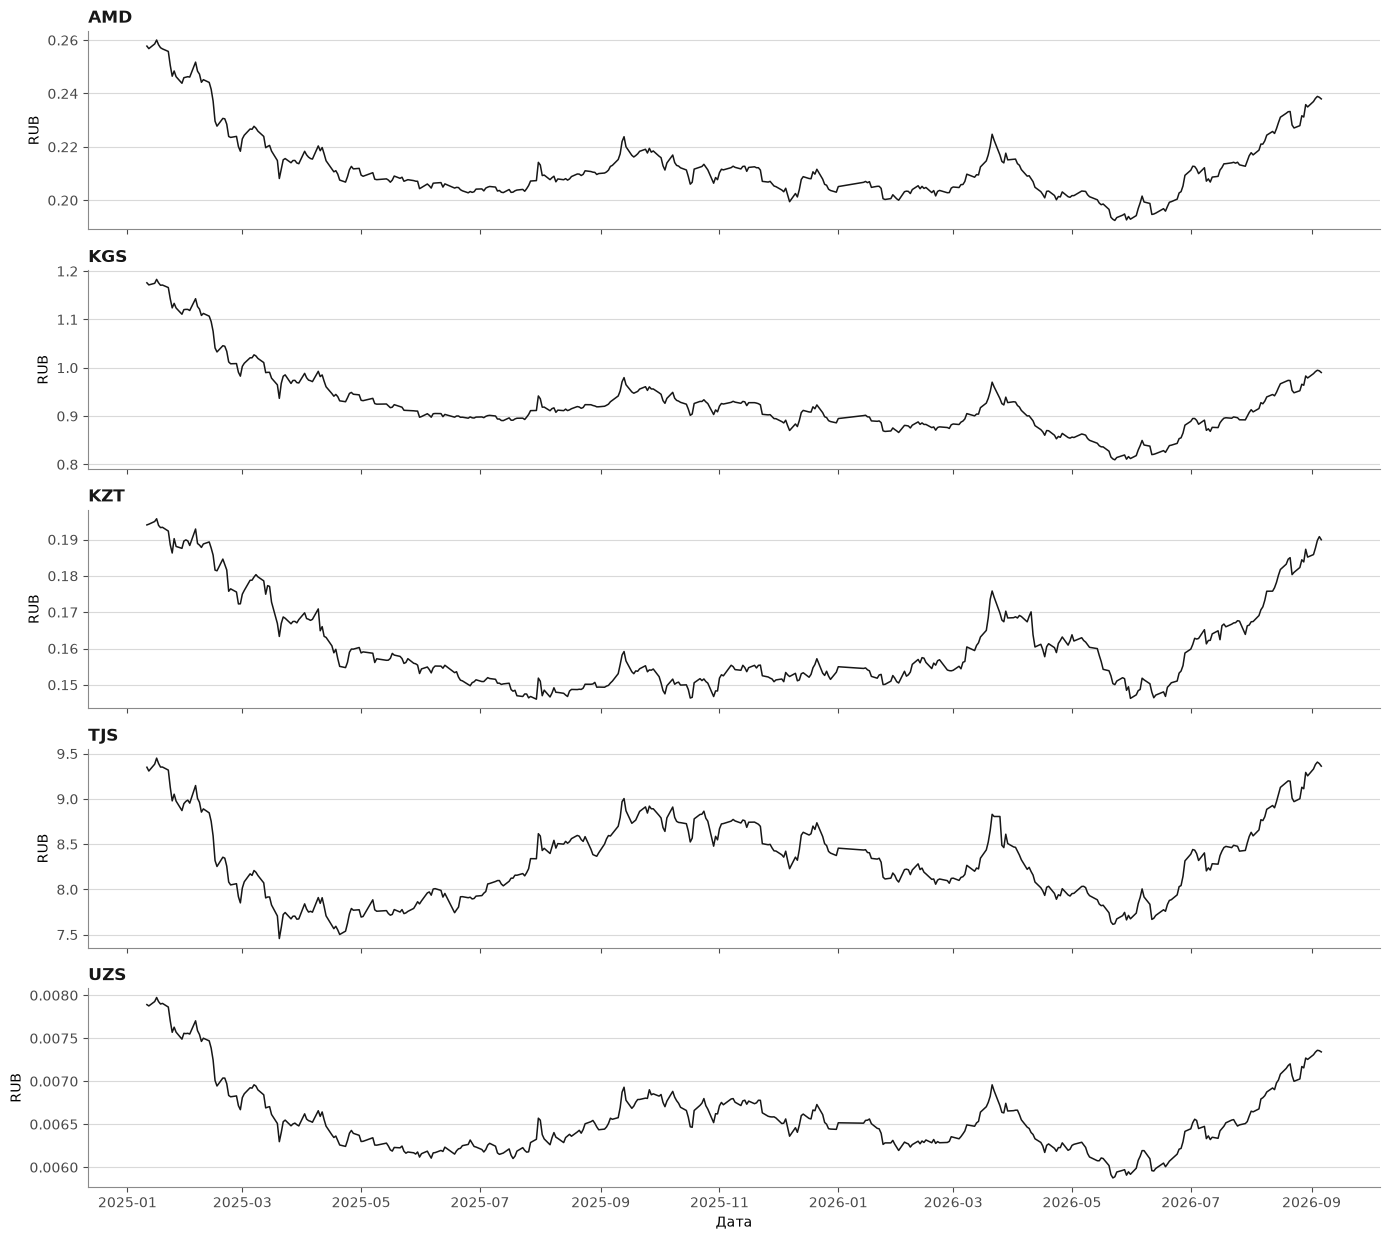

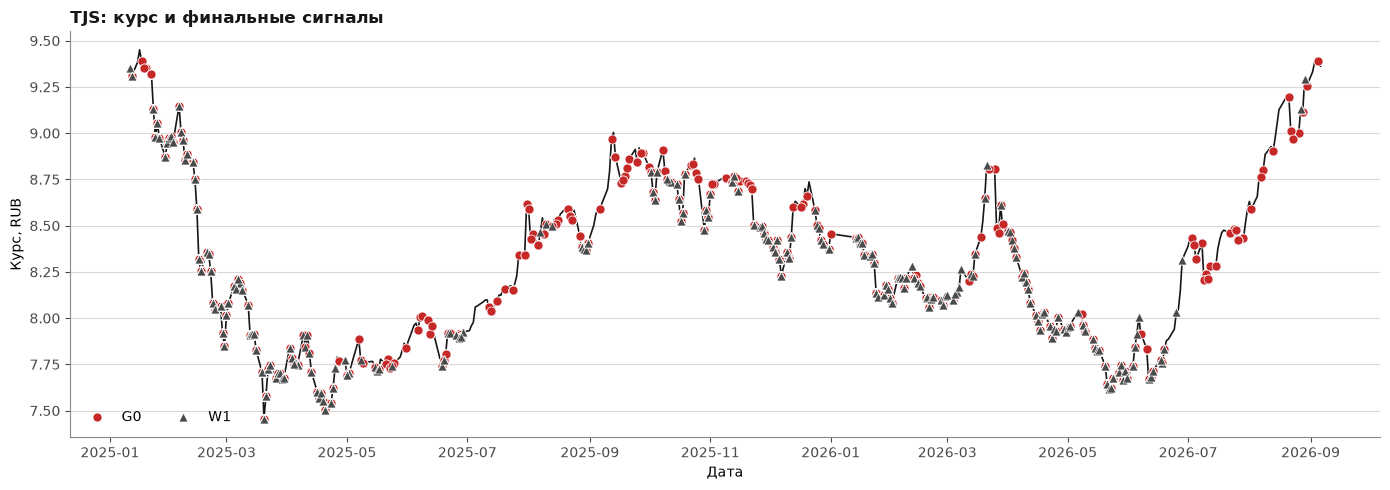

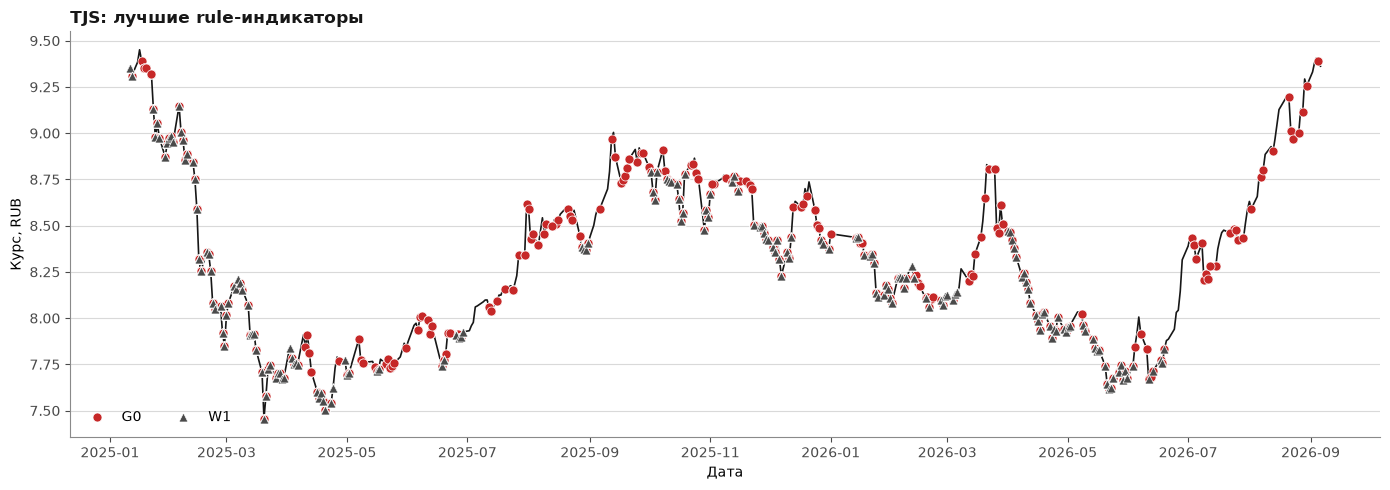

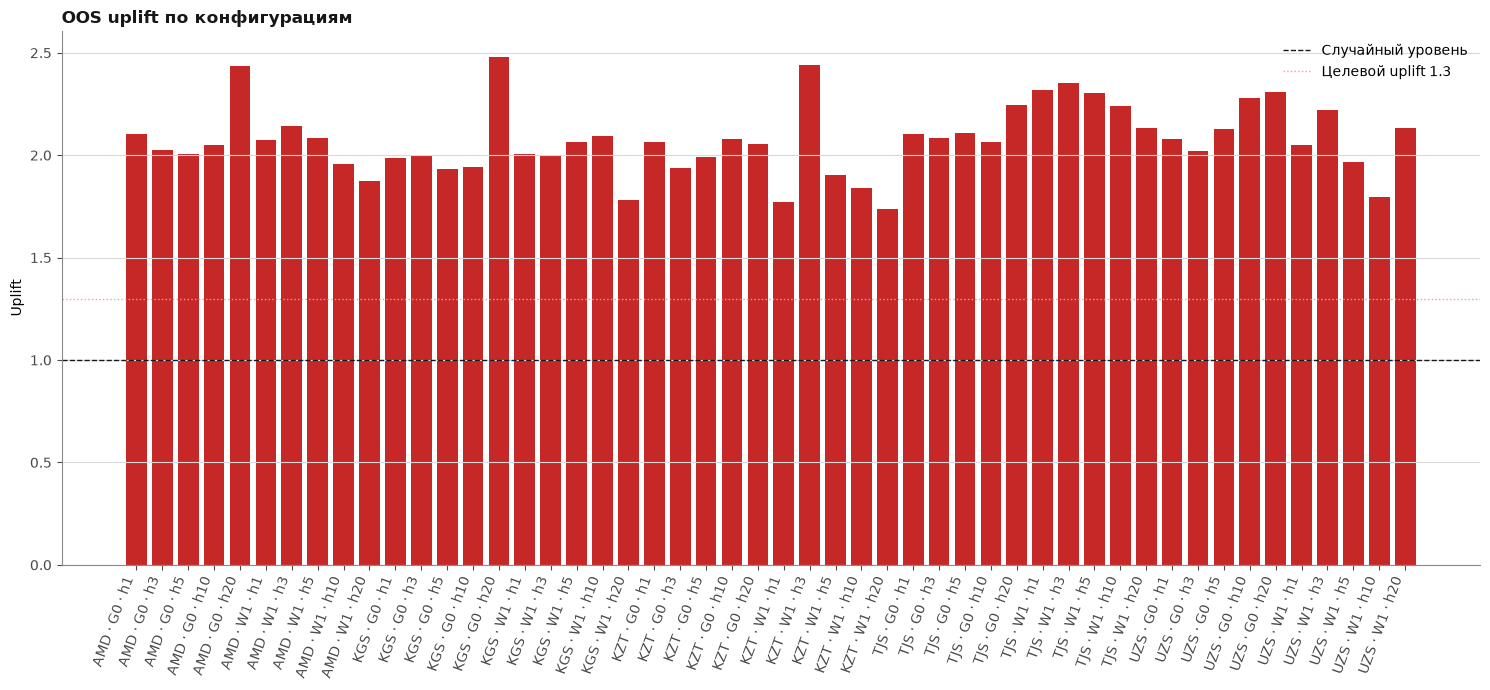

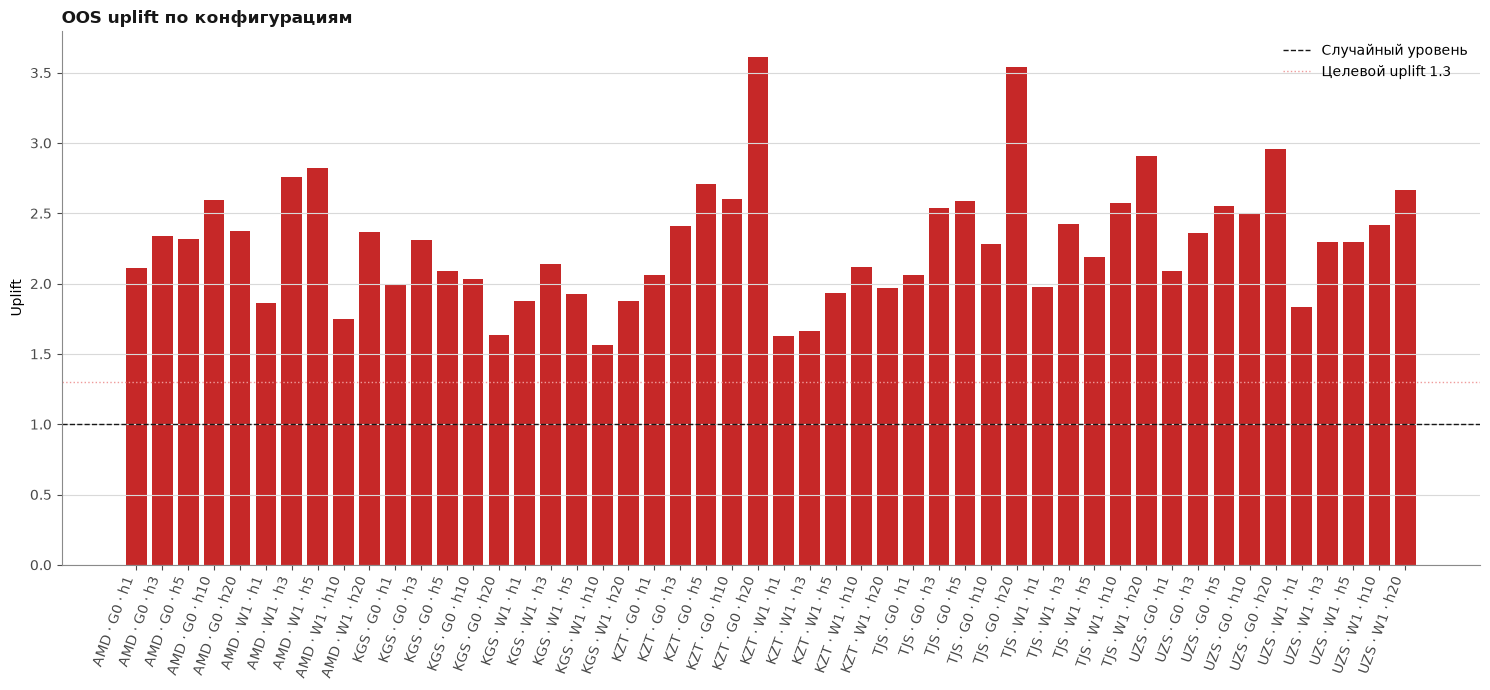

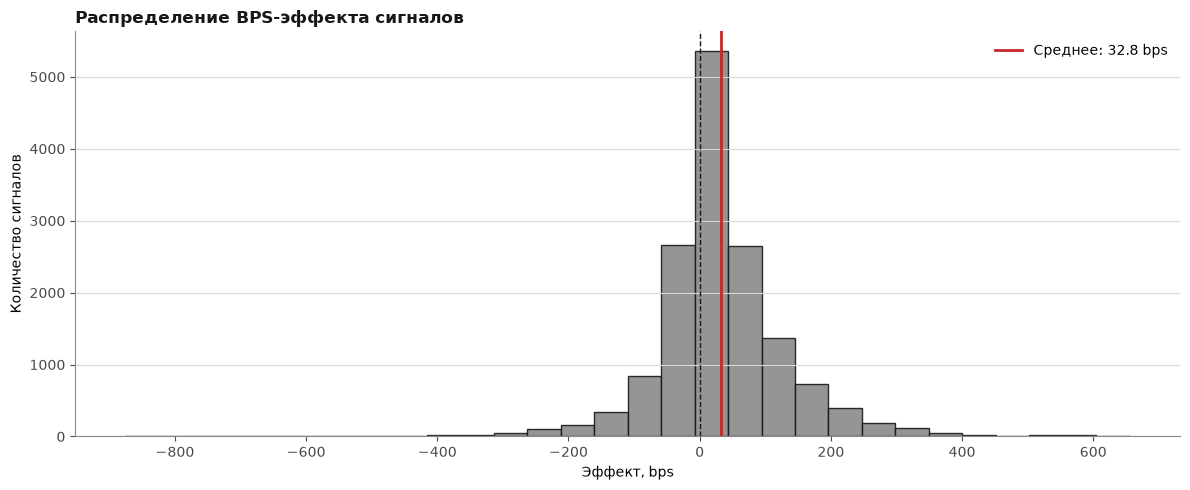

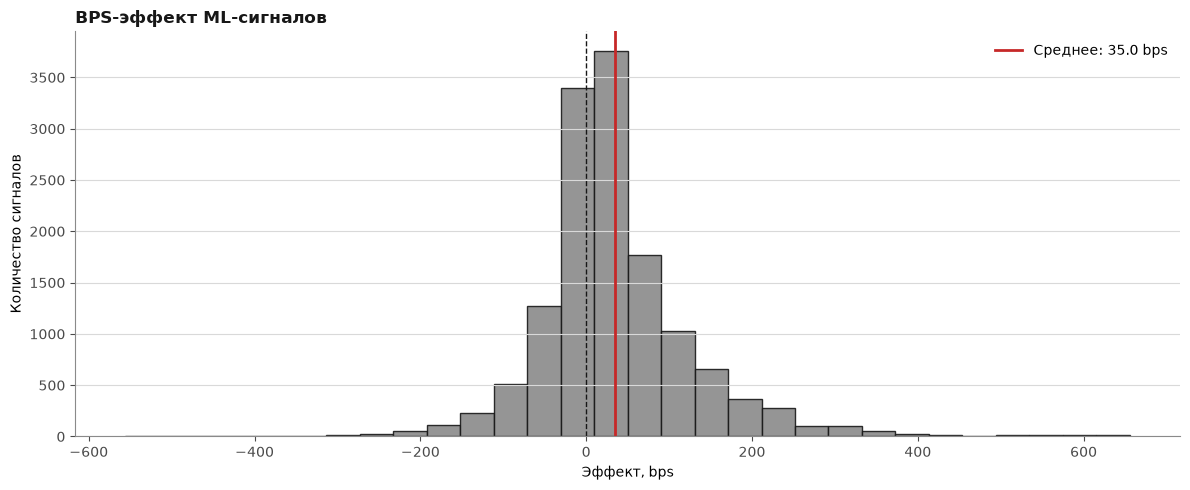

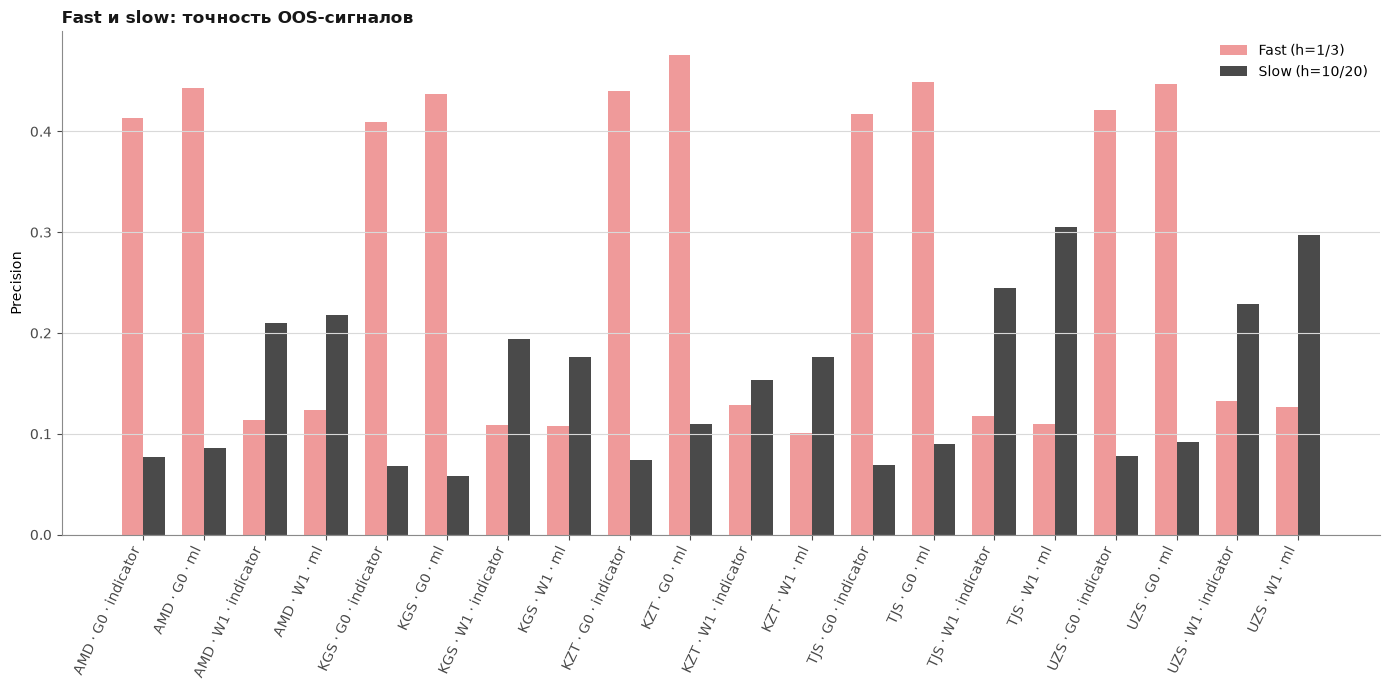

In [14]:
# Отдельная секция графиков для презентации.
import matplotlib.pyplot as plt
PRESENTATION_CURRENCY = 'TJS'
plot_rate_panel(update_rows)
plt.show()

plot_signal_series(
    update_rows,
    pd.concat([final_indicator_backtest_signals, final_ml_backtest_signals], ignore_index=True),
    currency=PRESENTATION_CURRENCY,
    start_date="2025-01-01",
)
plt.tight_layout()
plt.show()

plot_signal_series(
    update_rows, final_indicator_backtest_signals,
    currency=PRESENTATION_CURRENCY, start_date="2025-01-01",
    title=f"{PRESENTATION_CURRENCY}: лучшие rule-индикаторы",
)
plt.tight_layout()
plt.show()

plot_oos_uplift(final_indicator_backtest_summary)
plt.tight_layout()
plt.show()

plot_oos_uplift(final_ml_backtest_summary)
plt.tight_layout()
plt.show()

plot_benefit_distribution(_enrich_signals(final_indicator_backtest_signals))
plt.tight_layout()
plt.show()

plot_benefit_distribution(_enrich_signals(final_ml_backtest_signals), title="BPS-эффект ML-сигналов")
plt.tight_layout()
plt.show()

plot_fast_slow_summary(fast_slow_summary)
plt.tight_layout()
plt.show()